In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv')
df

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1
...,...,...,...,...,...,...,...,...,...
4995,organic_search,education,employed,asia,45834.0,2,2,0.37,1
4996,NaN,technology,employed,north_america,84831.0,2,5,0.51,0
4997,organic_search,finance,employed,asia,53636.0,4,6,0.75,1
4998,referral,technology,employed,africa,69430.0,4,8,0.79,1


In [5]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [6]:
numerical =['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
categorical =['lead_source', 'industry', 'employment_status', 'location']

In [7]:
df[numerical] = df[numerical].fillna(0)
df[categorical] = df[categorical].fillna('NA')
df

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NA,0.0,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1
...,...,...,...,...,...,...,...,...,...
4995,organic_search,education,employed,asia,45834.0,2,2,0.37,1
4996,NA,technology,employed,north_america,84831.0,2,5,0.51,0
4997,organic_search,finance,employed,asia,53636.0,4,6,0.75,1
4998,referral,technology,employed,africa,69430.0,4,8,0.79,1


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [11]:
from sklearn.metrics import roc_auc_score


0.7882254810906102

In [16]:
for num in numerical:
    print(f'variable : {num} AUC={roc_auc_score(df_train.converted, df_train[num])}')

variable : annual_income AUC=0.6081977776250831
variable : number_of_courses_viewed AUC=0.7229894623989618
variable : interaction_count AUC=0.7649203047563227
variable : lead_score AUC=0.7882254810906102


In [17]:
roc_auc_score(df_train.converted, df_train.number_of_courses_viewed)

0.7229894623989618

In [18]:
from sklearn.feature_extraction import DictVectorizer

In [19]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [21]:
y_train =df_train.converted
y_val = df_val.converted

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [30]:
round(roc_auc_score(y_val, model.predict_proba(X_val)[:,1]),3)

0.732

In [32]:
y_pred = model.predict_proba(X_val)[:,1]

In [33]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

precision = []
recall = []

thresholds = [0.01*i for i in range(101)]

for t in thresholds:

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    p = tp / (tp + fp)
    r = tp / (tp + fn)

    precision.append(p)
    recall.append(r)


/tmp/ipykernel_16273/3017112888.py:19: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


In [39]:
import matplotlib.pyplot as plt
%matplotlib inline

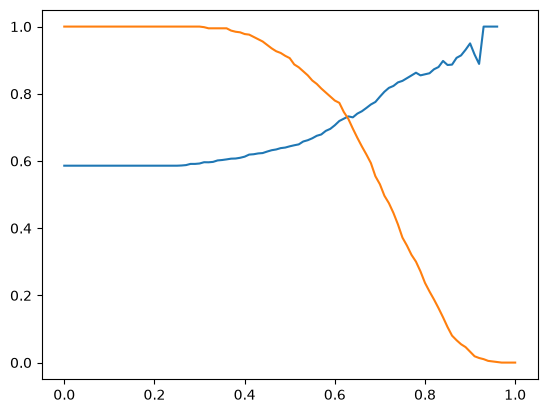

In [61]:
plt.plot(thresholds, precision)
plt.plot(thresholds, recall)

In [62]:
thresholds[np.argmin(((np.array(precision) - np.array(recall))/np.sign((np.array(precision) - np.array(recall))))[:95])]

0.63

In [63]:
np.argmin(((np.array(precision) - np.array(recall))/np.sign((np.array(precision) - np.array(recall))))[:95])

np.int64(63)

(0.6, 0.8)

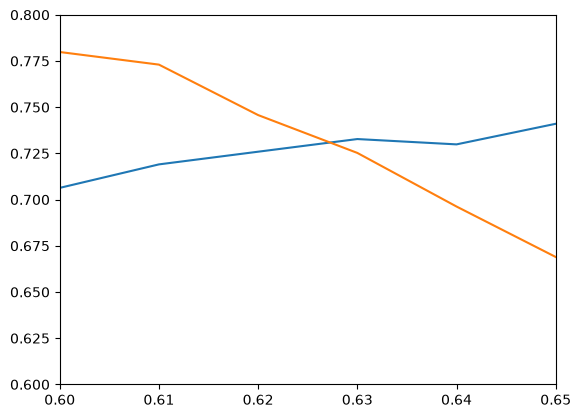

In [64]:
plt.plot(thresholds, precision)
plt.plot(thresholds, recall)
plt.xlim(0.6, 0.65)
plt.ylim(0.6, 0.8)

In [66]:
precision = np.array(precision)
recall = np.array(recall)

In [67]:
F1 = 2 * precision * recall / (precision + recall)

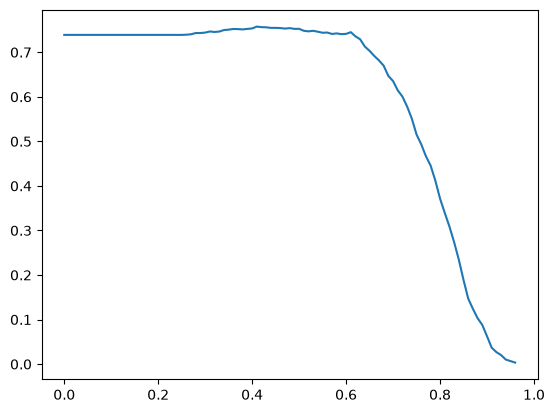

In [68]:
plt.plot(thresholds, F1)

In [71]:
thresholds[np.argmax(F1[:95])]

0.41000000000000003

In [73]:
from sklearn.model_selection import KFold

In [75]:
n_splits = 5

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    train_dict = df_train[categorical + numerical].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)

    val_dict = df_val[categorical + numerical].to_dict(orient='records')
    X_val = dv.transform(val_dict)

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_val)[:,1]

    score = roc_auc_score(y_val, y_pred)
    scores.append(score)
   
print(f'{np.mean(scores)} +- {np.std(scores)}')

0.7317269710972524 +- 0.006853233151022138


In [77]:
from tqdm.auto import tqdm

In [78]:
n_splits = 5

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)
    
    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        train_dict = df_train[categorical + numerical].to_dict(orient='records')
        X_train = dv.fit_transform(train_dict)

        val_dict = df_val[categorical + numerical].to_dict(orient='records')
        X_val = dv.transform(val_dict)

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train, y_train)
    
        y_pred = model.predict_proba(X_val)[:,1]

        score = roc_auc_score(y_val, y_pred)
        scores.append(score)
   
    print(f'C:{C} {np.mean(scores)} +- {np.std(scores)}')

  0%|          | 0/3 [00:00<?, ?it/s]

C:1e-06 0.6167342250714795 +- 0.018669799234831475
C:0.001 0.7491721776030379 +- 0.009996375455700753
C:1 0.7317269710972524 +- 0.006853233151022138
